<a href="https://colab.research.google.com/github/dbthyy/med-audio-synthetic-augmentation/blob/main/02_Data_Generating/Generating_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## 1. EDA

In [ ]:
!python 02_generative_model.py #without FAD

[Info] Will generate 453 synthetic COVID samples per model

=== Training VAE ===
VAE 1/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E001 loss=14158.3668 recon=14157.0077 kl=13.5916
VAE 2/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E002 loss=11805.8454 recon=11803.7127 kl=21.3266
VAE 3/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E003 loss=10356.5604 recon=10353.9669 kl=25.9352
VAE 4/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E004 loss=9510.1638 recon=9507.0207 kl=31.4302
VAE 5/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E005 loss=9106.9069 recon=9103.1986 kl=37.0836
VAE 6/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E006 loss=8802.3444 recon=8797.8685 kl=44.7587
VAE 7/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E007 loss=8619.2803 recon=8614.1710 kl=51.0934
VAE 8/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E008 loss=8499.4566 recon=8493.6089 kl=58.4774
VAE 9/200:   0%|          | 0/29 [00:00<?, ?it/s]
[VAE] E009 loss=8351.8895 recon=8345.40

In [ ]:
for fname in ['vae_samples.pt', 'gan_samples.pt', 'diffusion_samples.pt']:
    if os.path.exists(fname):
        t = torch.load(fname, map_location='cpu')
        print(f'  {fname}: {t.shape} | min={t.min():.3f} max={t.max():.3f}')
    else:
        print(f'  {fname}: NOT FOUND')

  vae_samples.pt: torch.Size([453, 1, 128, 94]) | min=0.000 max=1.000
  gan_samples.pt: torch.Size([453, 1, 128, 94]) | min=-0.750 max=0.987
  diffusion_samples.pt: torch.Size([453, 1, 128, 94]) | min=0.000 max=1.000


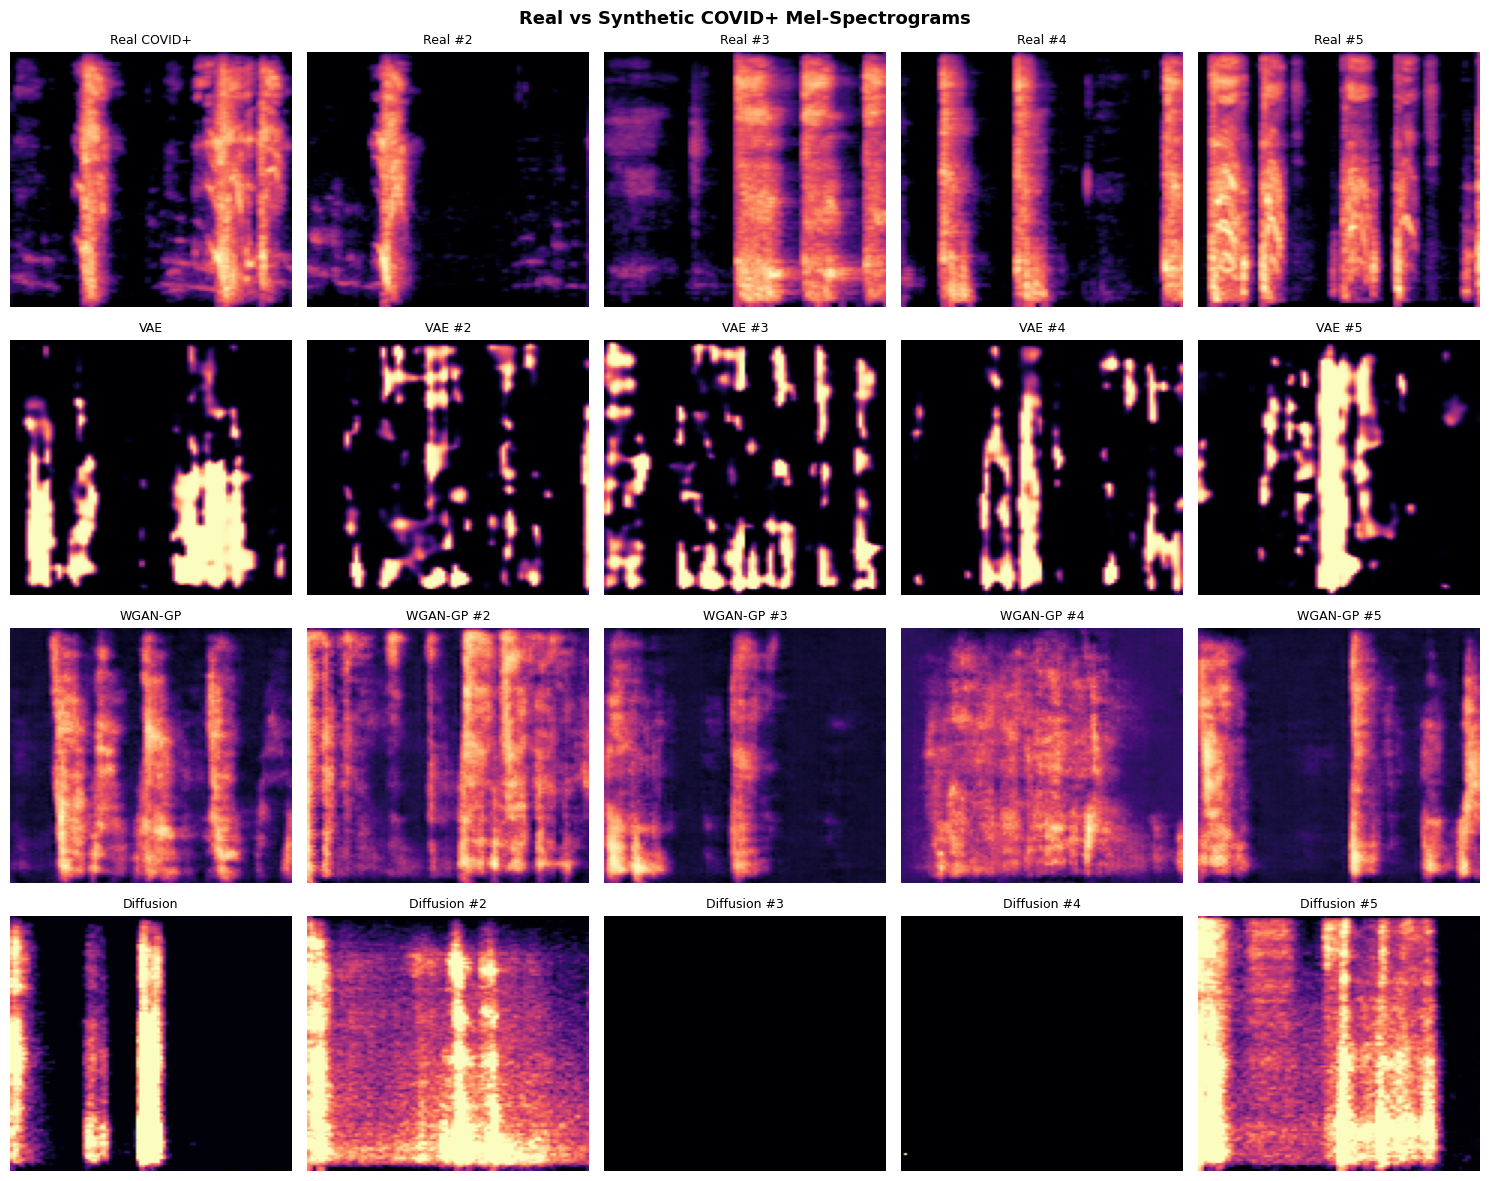

In [ ]:
import matplotlib.pyplot as plt

data = torch.load('dataset.pt', map_location='cpu')
y_train = data['y_train']
real_covid = data['X_train'][y_train == 1]  # (N, H, W, 1)

sample_files = {
    'VAE':       'vae_samples.pt',
    'WGAN-GP':   'gan_samples.pt',
    'Diffusion': 'diffusion_samples.pt',
}

loaded = {}
for name, path in sample_files.items():
    if os.path.exists(path):
        loaded[name] = torch.load(path, map_location='cpu')

n_cols = 5
n_rows = 1 + len(loaded)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
fig.suptitle('Real vs Synthetic COVID+ Mel-Spectrograms', fontsize=13, fontweight='bold')

# Real samples
for j in range(n_cols):
    spec = real_covid[j].squeeze().numpy()
    axes[0, j].imshow(spec, aspect='auto', origin='lower', cmap='magma')
    axes[0, j].set_title(f'Real #{j+1}' if j > 0 else 'Real COVID+', fontsize=9)
    axes[0, j].axis('off')

# Synthetic samples
for i, (name, samples) in enumerate(loaded.items(), 1):
    if samples.ndim == 4 and samples.shape[1] == 1:  # (N,1,H,W)
        samples_show = samples
    else:
        samples_show = samples.permute(0,3,1,2) if samples.ndim==4 else samples.unsqueeze(1)
    for j in range(n_cols):
        spec = samples_show[j, 0].numpy()
        axes[i, j].imshow(spec, aspect='auto', origin='lower', cmap='magma')
        axes[i, j].set_title(f'{name} #{j+1}' if j > 0 else name, fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('plot_02_synthetic_spectrograms.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. Fréchet Audio Distance (FAD)

Đánh giá **chất lượng** dữ liệu sinh — FAD thấp hơn = gần real hơn.

In [ ]:
# tính fad trên epoch cuối (epoch mà orignial paper sử dụng)
!python 03_evaluate_fad.py

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 128MB/s]
Extracting features from real COVID+ samples...
/content/drive/MyDrive/MEDICAL-PROJECT/03_evaluate_fad.py:70: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)

                   FAD EVALUATION RESULTS                   
  [Reference] FAD (Real vs Real split): 29.3911
  (Lower bound — FAD tốt nhất có thể đạt)
------------------------------------------------------------
  FAD (Real vs WGAN-GP     ): 143.2825  [+113.8914 vs baseline]
  FAD (Real vs Diffusion   ): 170.5464  [+141.1553 vs baseline]
  FAD (Real vs VAE         ): 236.5703  [+207.1793 vs baseline]
  (*) FAD thấp hơn = dữ liệu sinh gần thật hơn.
  (*) FAD (Real vs Real) là điểm tham chiếu lý tưởng.


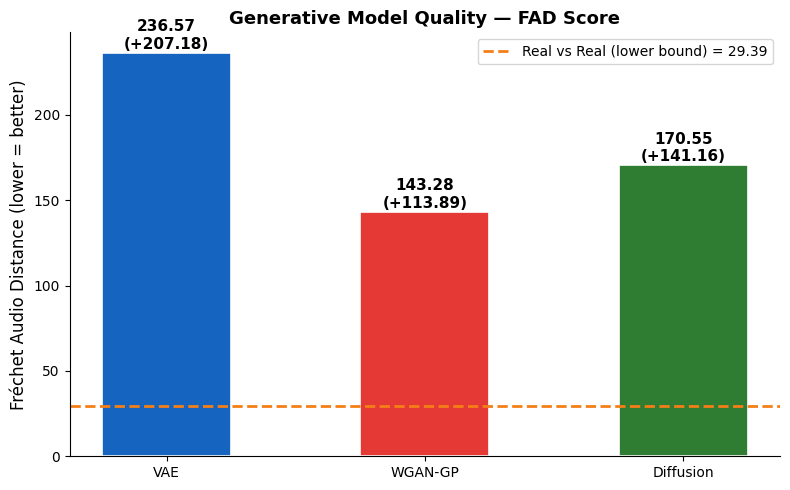

In [ ]:
# Visualize FAD scores
fad_baseline = 29.3911   # Real vs Real split (lower bound)
fad_scores   = {
    'VAE':       236.5703,
    'WGAN-GP':   143.2825,
    'Diffusion': 170.5464,
}

if all(v is not None for v in fad_scores.values()) and fad_baseline is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    models   = list(fad_scores.keys())
    scores   = list(fad_scores.values())
    colors   = ['#1565C0', '#E53935', '#2E7D32']

    bars = ax.bar(models, scores, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
    ax.axhline(fad_baseline, color='#F57F17', linestyle='--', linewidth=2.0,
               label=f'Real vs Real (lower bound) = {fad_baseline:.2f}')

    for bar, s in zip(bars, scores):
        gap = s - fad_baseline
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{s:.2f}\n(+{gap:.2f})', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    ax.set_ylabel('Fréchet Audio Distance (lower = better)', fontsize=12)
    ax.set_title('Generative Model Quality — FAD Score', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('plot_03_fad_scores.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Chưa có FAD scores. Chạy file 03 và điền kết quả vào cell này.')

---
## 3. Train Generative Models with FAD

3 mô hình sinh được train **chỉ trên COVID+ samples**:
- **VAE**: 200 epochs, Adam lr=1e-4, β=0.1
- **WGAN-GP**: 300 epochs, RMSprop lr=5e-5, λ_gp=10, n_critic=5
- **Diffusion**: 400 epochs, AdamW lr=1e-4, T=1000 steps

Mỗi model sinh **558 synthetic samples** (50% of 1116 COVID+ train samples).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/02_Data_Generating")
os.listdir()

['implement.ipynb',
 'dataset.pt',
 'data',
 'models',
 'training',
 'evaluation',
 'utils',
 'main.py',
 'readme.md',
 'config.py',
 '__pycache__',
 'vae',
 '.ipynb_checkpoints',
 'metrics',
 'plots',
 'plot_00_class_distribution.png']

### VAE

In [ ]:
!python main.py --mode reproduce  --model vae  --ckpt_dir vae/


  Mode    : REPRODUCE
  Model   : vae
  Adaptive: False
  VAE β=0.1  |  GAN base=64  |  Diff mini_bs=8
  eval_every=25 epochs
  Generate from: BEST checkpoint

[Info] COVID+ samples : 906
[Info] Will generate  : 453 synthetic samples per model
[Info] Device         : cuda

[Info] Initialising FAD extractor (ResNet-18) …
[Info] FAD extractor ready.

  VAE
[VAE] E001  loss=14498.8098  recon=14497.4246  kl=13.8517
[VAE] E002  loss=12307.3298  recon=12305.4031  kl=19.2679
[VAE] E003  loss=10570.1861  recon=10567.6120  kl=25.7407
[VAE] E004  loss=9623.8462  recon=9620.7745  kl=30.7176
[VAE] E005  loss=9137.7997  recon=9133.8963  kl=39.0346
[VAE] E006  loss=8834.4662  recon=8829.7824  kl=46.8391
[VAE] E007  loss=8609.7563  recon=8604.3224  kl=54.3390
[VAE] E008  loss=8435.8349  recon=8429.6703  kl=61.6465
[VAE] E009  loss=8328.7761  recon=8322.0567  kl=67.1943
[VAE] E010  loss=8191.2980  recon=8183.9947  kl=73.0334
[VAE] E011  loss=8092.4061  recon=8084.5644  kl=78.4169
[VAE] E012  loss=795

- Nếu chạy theo original paper: lấy final epoch ~ FAD CAO   FAD=210.31
--> Tối ưu bằng cách: Best FAD achieved: 178.75 @ epoch 75

In [ ]:
!python main.py --mode improve  --model vae  --ckpt_dir checkpoints/improve


  Mode    : IMPROVE
  Model   : vae
  Adaptive: True
  VAE β=0.05  |  GAN base=128  |  Diff mini_bs=8
  eval_every=25 epochs
  Generate from: BEST checkpoint
  Metrics  → metrics/<model>.jsonl

[Info] COVID+ samples: 906
[Info] Will generate : 453 synthetic samples per model
[Info] Device        : cuda

[Info] Initializing FAD extractor (ResNet18)...
[Info] FAD extractor ready.

  VAE
[VAE] E001  loss=13941.1894  recon=13940.3476  kl=16.8358
[VAE] E002  loss=11530.2073  recon=11529.1461  kl=21.2223
[VAE] E003  loss=10085.3528  recon=10084.0062  kl=26.9300
[VAE] E004  loss=9369.5736  recon=9367.8373  kl=34.7257
[VAE] E005  loss=8972.5209  recon=8970.4225  kl=41.9671
[VAE] E006  loss=8663.4992  recon=8661.0222  kl=49.5400
[VAE] E007  loss=8511.4234  recon=8508.5490  kl=57.4867
[VAE] E008  loss=8420.2019  recon=8416.9693  kl=64.6521
[VAE] E009  loss=8285.9846  recon=8282.4008  kl=71.6764
[VAE] E010  loss=8186.0327  recon=8182.1445  kl=77.7626
[VAE] E011  loss=8067.7473  recon=8063.5550  

In [ ]:
!python 02_generative_models.py --mode improve  --model vae  --ckpt_dir checkpoints/improve


  Mode    : IMPROVE
  Model   : vae
  Adaptive: True
  VAE β=0.05  |  GAN base=128  |  Diff mini_bs=8
  eval_every=25 epochs
  Generate from: BEST checkpoint
  Metrics  → metrics/<model>.jsonl

[Info] COVID+ samples: 906
[Info] Will generate : 453 synthetic samples per model
[Info] Device        : cuda

[Info] Initializing FAD extractor (ResNet18)...
[Info] FAD extractor ready.

  VAE
[VAE] E001  loss=13941.1894  recon=13940.3476  kl=16.8358
[VAE] E002  loss=11530.2073  recon=11529.1461  kl=21.2223
[VAE] E003  loss=10085.3528  recon=10084.0062  kl=26.9300
[VAE] E004  loss=9369.5736  recon=9367.8373  kl=34.7257
[VAE] E005  loss=8972.5209  recon=8970.4225  kl=41.9671
[VAE] E006  loss=8663.4992  recon=8661.0222  kl=49.5400
[VAE] E007  loss=8511.4234  recon=8508.5490  kl=57.4867
[VAE] E008  loss=8420.2019  recon=8416.9693  kl=64.6521
[VAE] E009  loss=8285.9846  recon=8282.4008  kl=71.6764
[VAE] E010  loss=8186.0327  recon=8182.1445  kl=77.7626
[VAE] E011  loss=8067.7473  recon=8063.5550  

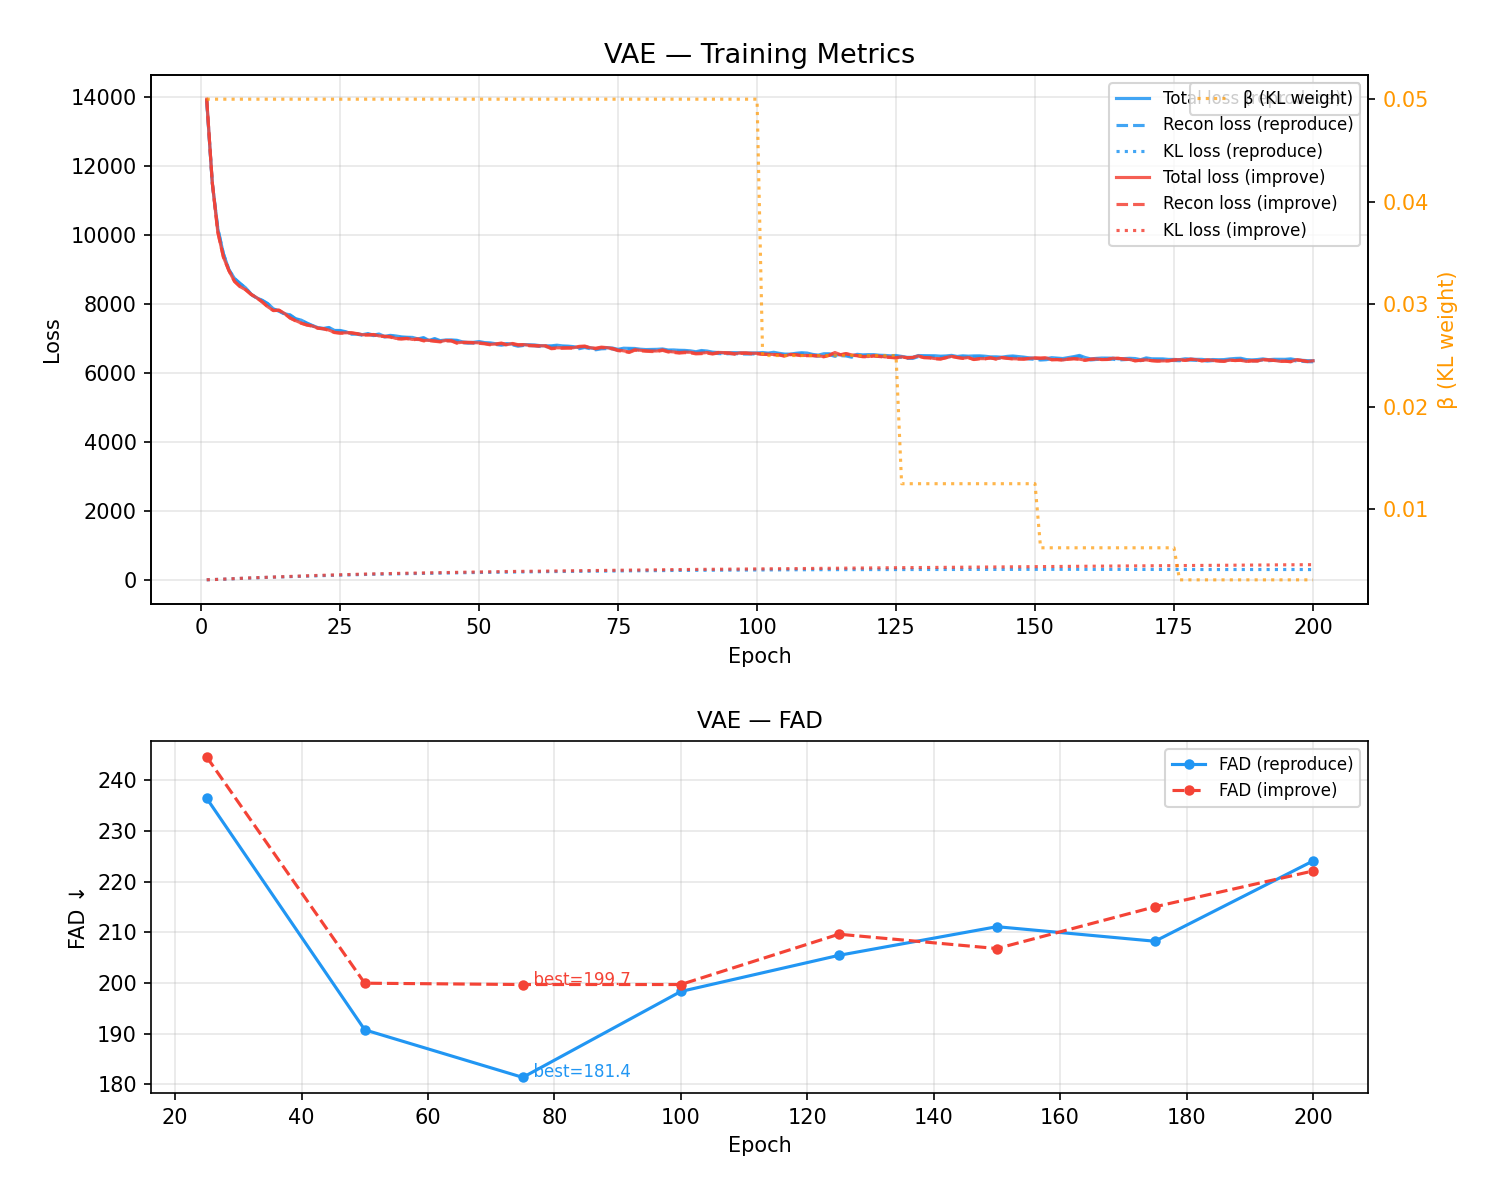

In [6]:
!python 02_generative_models.py --mode all --model vae --plot

### WGAN

In [ ]:
import os
os.chdir("/content/drive/MyDrive/WGAN")

In [ ]:
!python 02_generative_models.py --mode reproduce  --model wgan  --ckpt_dir checkpoints/reproduce


  Mode    : REPRODUCE
  Model   : wgan
  Adaptive: False
  VAE β=0.1  |  GAN base=64  |  Diff mini_bs=8
  eval_every=25 epochs
  Metrics  → metrics/<model>.jsonl

[Info] COVID+ samples: 906
[Info] Will generate : 453 synthetic samples per model
[Info] Device        : cuda

[Info] Initializing FAD extractor (ResNet18)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 80.3MB/s]
[Info] FAD extractor ready.

  WGAN-GP
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[GAN] E001  D=5.5458  G=-0.0903
[GAN] E002  D=4.9516  G=-0.0925
[GAN] E003  D=4.0400  G=-0.0

In [ ]:
!python 02_generative_models.py --mode improve  --model wgan  --ckpt_dir checkpoints/improve


  Mode    : IMPROVE
  Model   : wgan
  Adaptive: True
  VAE β=0.05  |  GAN base=128  |  Diff mini_bs=8
  eval_every=25 epochs
  Generate from: BEST checkpoint
  Metrics  → metrics/<model>.jsonl

[Info] COVID+ samples: 906
[Info] Will generate : 453 synthetic samples per model
[Info] Device        : cuda

[Info] Initializing FAD extractor (ResNet18)...
[Info] FAD extractor ready.

  WGAN-GP
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[GAN] E001  D=4.9505  G=0.0468
[GAN] E002  D=4.4206  G=0.1421
[GAN] E003  D=0.6041  G=0.5741
[GAN] E004  D=-0.3552  G=0.6019
[GAN] E005  D=-0.4467  G=-0.1745
[GAN] E006  D=-0.8204  G=0.3403
[GAN] E007  D=-2.1992  G=0.8618
[GAN] E008  

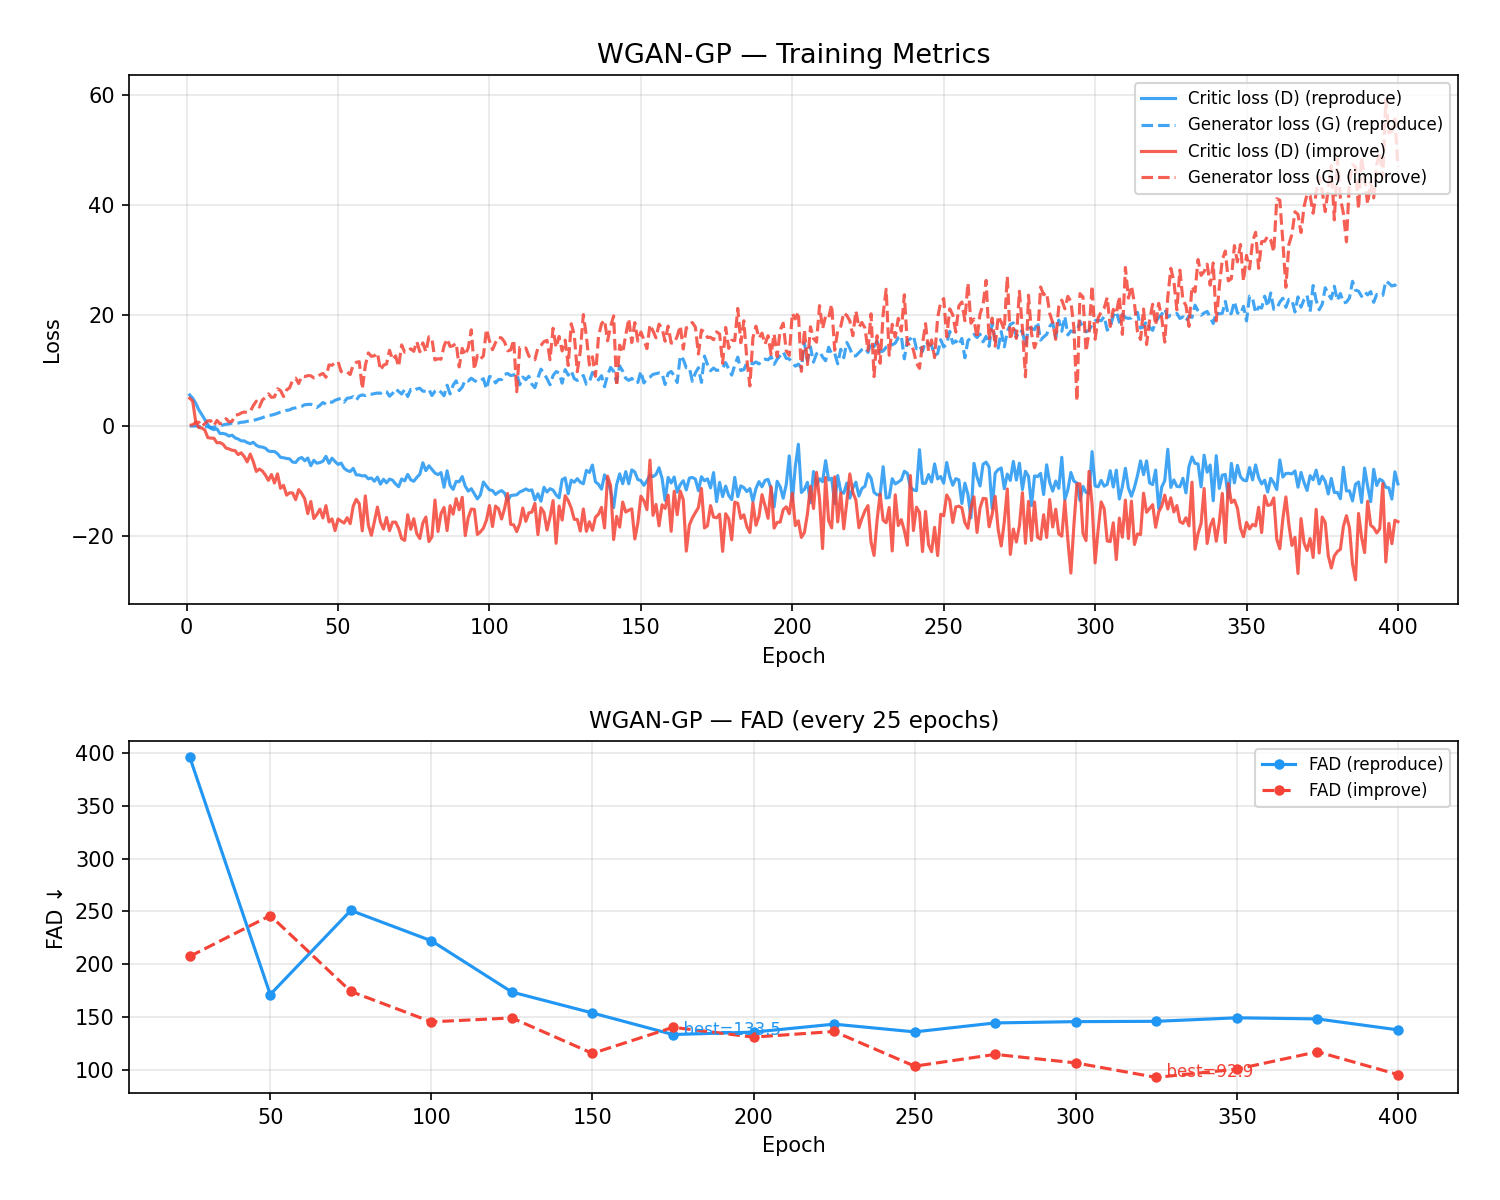

In [7]:
!python 02_generative_models.py --mode all --model wgan --plot

### DDPM
Vì thời gian chạy đặc thù, cần triển khai trên 1 nền tảng khác, truy cập tại:
* Reproduce: https://www.kaggle.com/code/baothydinh/diffusion-reproduce
* Improve: https://www.kaggle.com/code/dbtthy/diffusion-improve?scriptVersionId=323555310

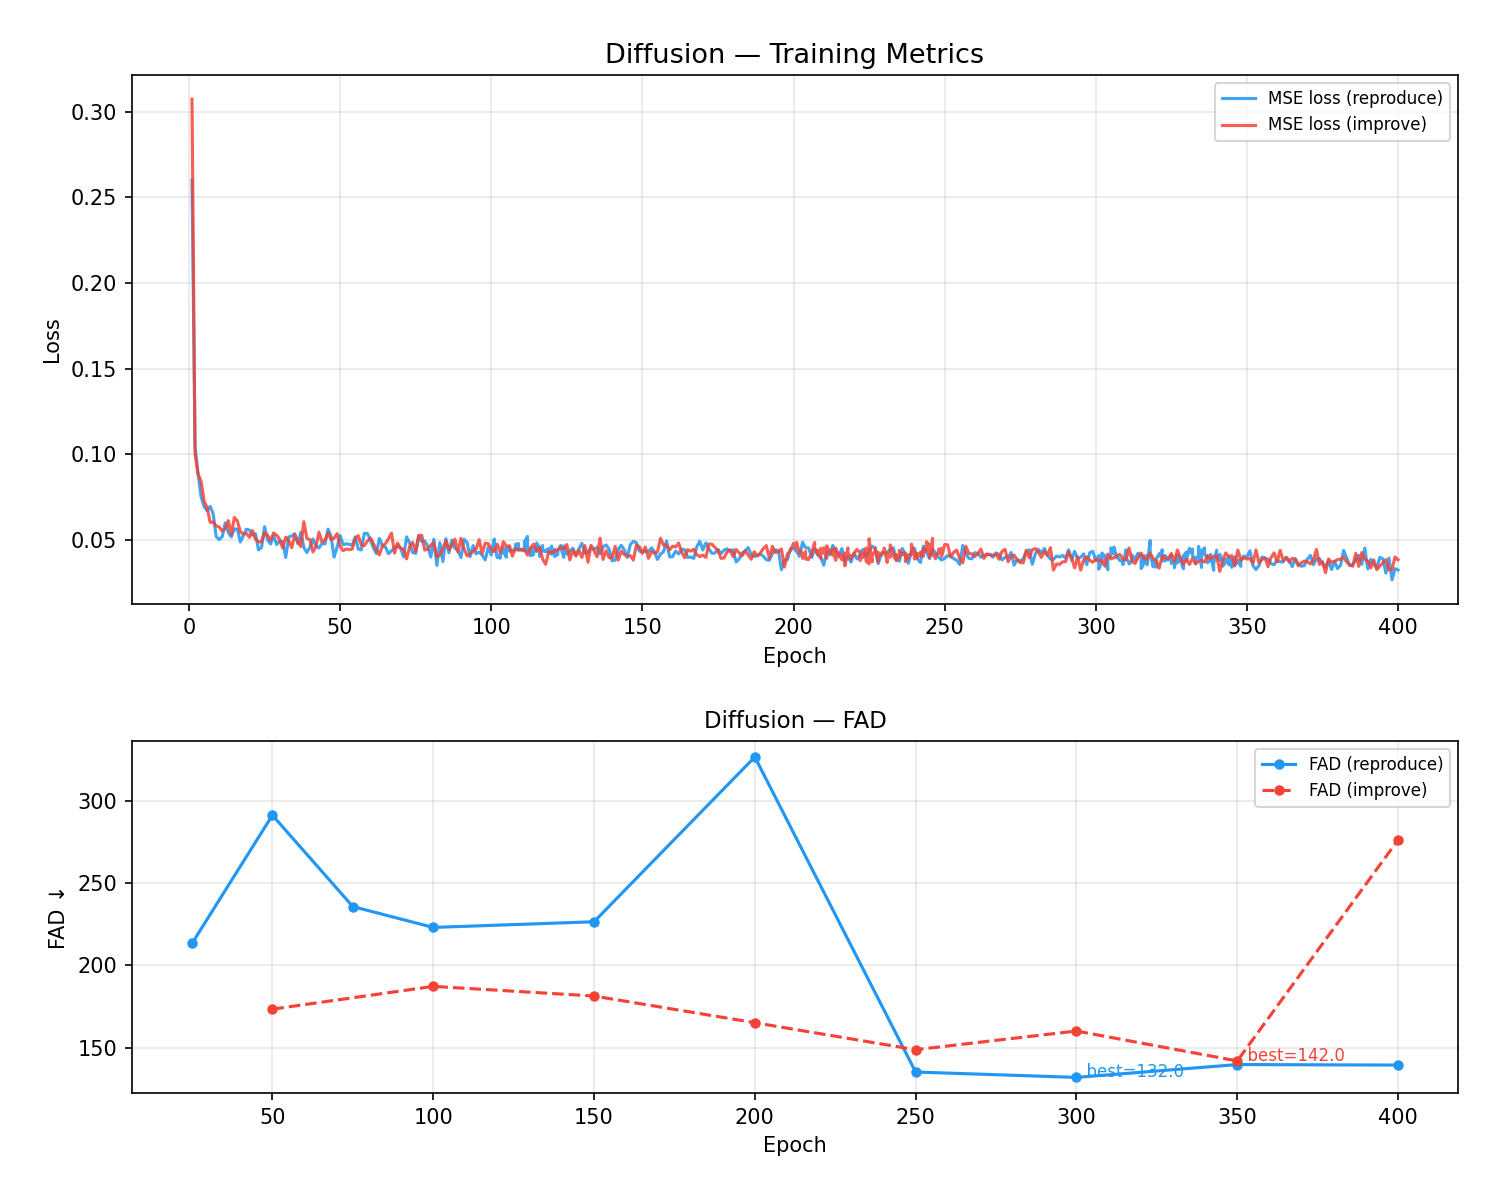

In [8]:
!python 02_generative_models.py --mode all --model diffusion --plot